In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 1. Загрузка данных
df = pd.read_csv("hypertension_dataset.csv")

In [ ]:
# Информация о форме и типах
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (1985, 11)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB


Набор данных содержит 1985 записей и 11 признаков. Большинство признаков, включая целевую переменную 'Has_Hypertension', имеют категориальный тип ('object') и потребуют кодирования для анализа или построения моделей.

In [ ]:
# Проверка пропусков по столбцам
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64


Обнаружены пропущенные значения только в столбце 'Medication' (799 из 1985 записей), что требует дальнейшей обработки.

In [ ]:
# 2. Очистка и предварительная обработка данных

# Заполняем пропуски в Medication значением 'None'
df['Medication'] = df['Medication'].fillna('None')

# Преобразуем BP_History в числовую шкалу
bp_history_mapping = {'Normal': 0, 'Prehypertension': 1, 'Hypertension': 2}
df['BP_History'] = df['BP_History'].map(bp_history_mapping)

# Закодируем категориальные признаки методом one-hot encoding
categorical_cols = ['Family_History', 'Exercise_Level', 'Smoking_Status', 'Medication']
# drop_first=True уменьшает мультиколлинеарность, dtype=int делает столбцы целочисленными
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# Преобразуем целевую переменную в 0/1
df['Has_Hypertension'] = df['Has_Hypertension'].map({'Yes': 1, 'No': 0})


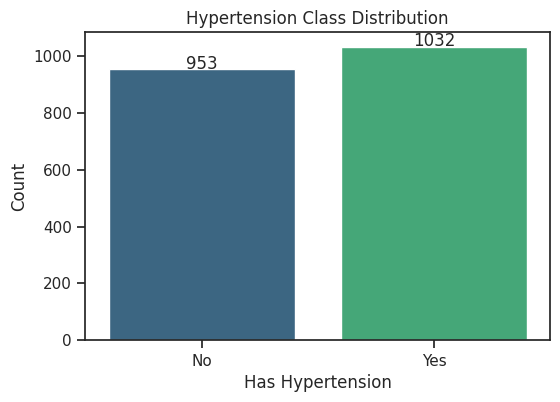

In [ ]:
# 3. Визуализация: распределение классов
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Has_Hypertension', palette='viridis')
plt.title("Hypertension Class Distribution")
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel("Has Hypertension")
plt.ylabel("Count")

# Добавляем подписи с числом над каждым столбцом
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 3,
            '{:.0f}'.format(height),
            ha="center")

plt.show()


Данные относительно сбалансированы между двумя классами («есть гипертония» и «нет гипертонии»), при этом гипертония встречается немного чаще. Это говорит о том, что гипертония является распространённой проблемой среди рассматриваемой группы.

In [ ]:
# 4. Расчёт дисбаланса классов
if 'Has_Hypertension' in df.columns:
    c0, c1 = df['Has_Hypertension'].value_counts().reindex([0,1], fill_value=0).astype(int)
    if c0 + c1 == 0:
        print("Нет данных в целевой переменной.")
    elif c0 == 0 or c1 == 0:
        print("Присутствует только один класс. Дисбаланс бесконечен.")
    else:
        maj, min_ = max(c0, c1), min(c0, c1)
        print(f"Соотношение классов (major:minor): {maj/min_:.2f}:1")
else:
    print("Столбца 'Has_Hypertension' нет в DataFrame.")


Соотношение классов (major:minor): 1.08:1


Классы практически сбалансированы. Количество экземпляров в одном классе лишь незначительно превышает количество в другом (соотношение близко к 1:1). Это означает, что проблема дисбаланса классов незначительна и не требует специальных методов для борьбы с дисбалансом.

In [ ]:
# 5. Визуализация распределений и корреляций

# Список числовых признаков
numeric_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI', 'BP_History']



## Pairplot
Дает комплексное визуальное представление о попарных взаимосвязях числовых признаков и их распределениях, дифференцированных по наличию гипертонии, помогая выявить кластеры или разделения.

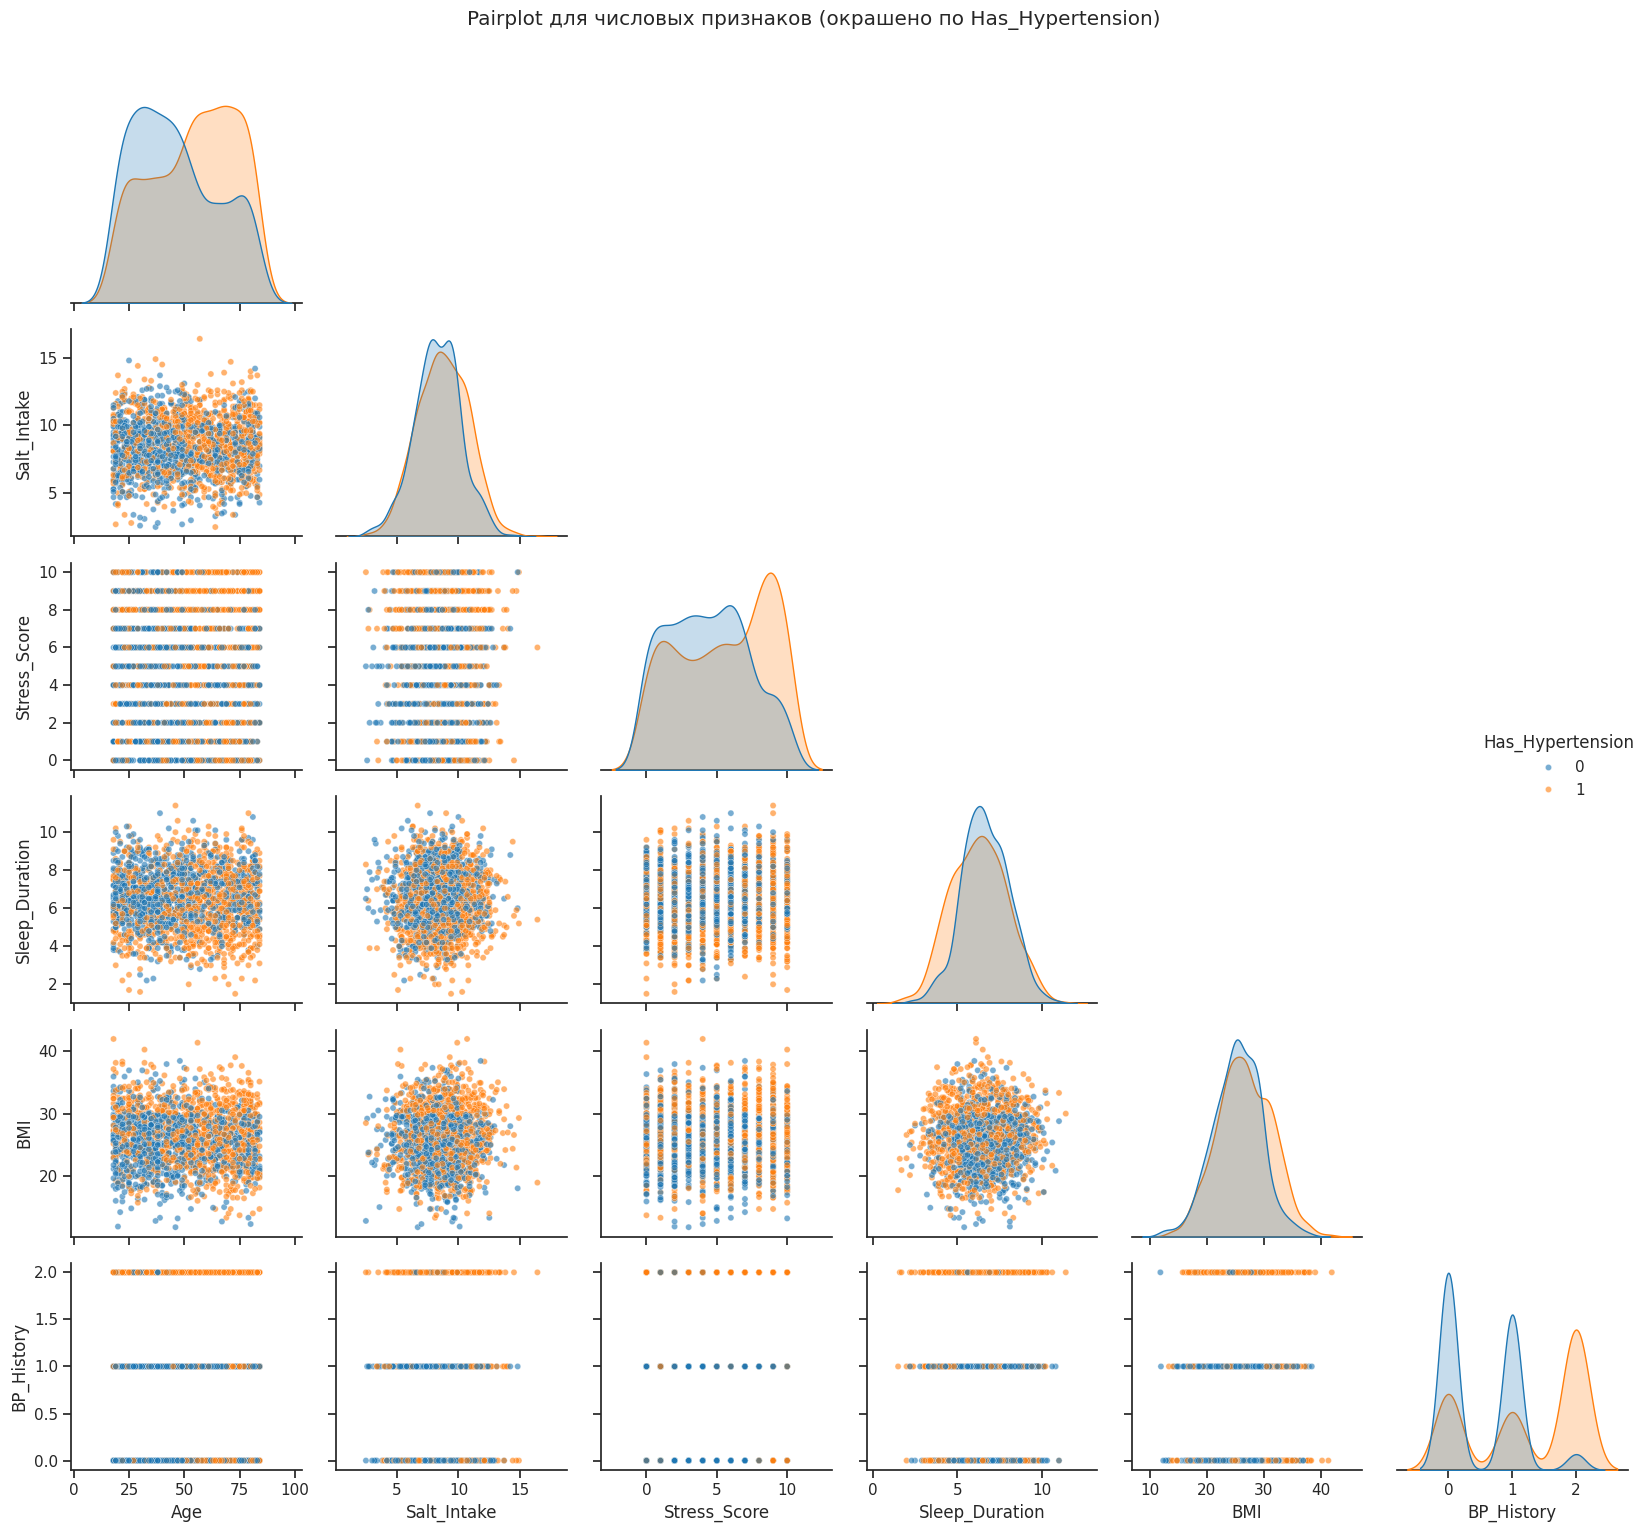

In [ ]:
#  pairplot
pp_df = df.copy()

# Настройки pairplot: hue по целевой, диагональ — KDE, corner=True чтобы не дублировать зеркальные графики
sns.set(style="ticks", context="notebook")
pairplot = sns.pairplot(
    pp_df,
    vars=numeric_cols,
    hue='Has_Hypertension',
    palette={0: "tab:blue", 1: "tab:orange"},
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 20},
    diag_kws={'shade': True}
)

pairplot.fig.suptitle("Pairplot для числовых признаков (окрашено по Has_Hypertension)", y=1.02)
plt.tight_layout()


# Pairplot показывает распределение числовых признаков (Age, Salt_Intake, Stress_Score, Sleep_Duration, BMI, BP_History) в зависимости от наличия гипертонии (Has_Hypertension: 0 — нет, 1 — есть).
## Анализ:

### 1. Распределения:
   
*   Age (Возраст): Люди с гипертонией (оранжевые) в среднем старше, чем без (синие). Видна заметная асимметрия — пик оранжевых смещён вправо.
*   Salt_Intake (Потребление соли): Незначительное отличие, но у гипертоников потребление чуть выше.
*   Stress_Score (Стресс): У людей с гипертонией уровни стресса выше (график оранжевой линии смещён вправо)
*   Sleep_Duration (Продолжительность сна): Оранжевая кривая смещена влево, то есть люди с гипертонией спят меньше.
*   BMI: Люди с гипертонией имеют больший индекс массы тела.
*   BP_History (История давления): У гипертоников значения этого признака выше (и распределение отличается).

### 2. Взаимосвязи между признаками:
   Прямых явных кластеров на диагональных рассеянных графиках (scatter) нет, но видна тенденция: у гипертоников часто наблюдается сочетание повышенного возраста, выше потребление соли, больше стресс, меньше сна и больший BMI.
   BP_History хорошо разделяет две группы.

# Вывод:

Главные факторы, связанные с наличием гипертонии: возраст, уровень стресса, продолжительность сна, индекс массы тела и история давления.
Гипертония больше характерна для людей старшего возраста, с более высоким стрессом, меньшей продолжительностью сна, большим индексом массы тела и историей проблем с давлением.
Потребление соли также влияет, но не критически разделяет (есть пересечения).
BP_History — самый сильный разделяющий фактор (очевидное смещение).

## Гистограммы
Отображают распределение каждого отдельного признака, позволяя оценить его форму, центральную тенденцию и наличие выбросов.

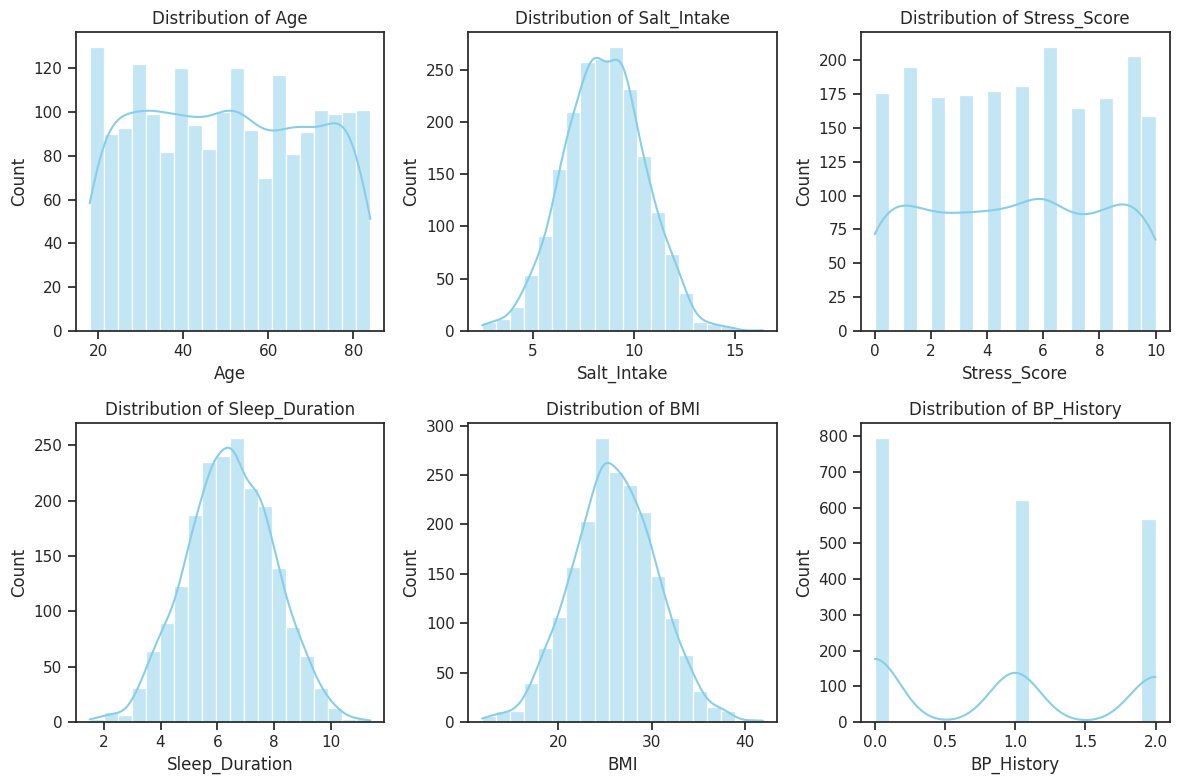

In [ ]:
# Distribution
numeric_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI', 'BP_History']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Анализ распределений данных:
1. Возраст (Age):

*   Распределение довольно равномерное со склонностью к легкой концентрации в средней части. Нет ярко выраженных выбросов или аномалий. Широкий диапазон возрастов (от 20 до 80 лет).
*   Вывод: Данные включают людей разных возрастов, без перекоса к какой-либо возрастной группе.

2. Потребление соли (Salt_Intake):

*   Данное распределение близко к нормальному (колоколообразная форма), большинство людей потребляют от 7 до 11 единиц соли.
*   Вывод: Потребление соли в основном умеренное, экстремальные значения редки.

3. Оценка стресса (Stress_Score):

*   Распределение почти равномерное — на каждом уровне стресса много наблюдений.
*   Вывод: В выборке хорошо представлены люди с разным уровнем стресса, распределение без выраженного смещения.


4. Продолжительность сна (Sleep_Duration):

*   Колоколообразное распределение, большинство данных в диапазоне 5-8 часов сна.
*   Вывод: В основном участники спят среднее количество часов, экстремальные значения (ниже 4 и выше 8) встречаются редко.


5. ИМТ (BMI):

*   Почти нормальное распределение, основной диапазон 20-35.
*   Вывод: ИМТ большинства участников в пределах нормы или небольшой избыточный вес, аномальные значения редки.


6. История давления (BP_History):

*   Категориальная переменная: три выраженных столбца (0, 1, 2), большинство в категории 0 и 1.
*   Вывод: Большинство участников или не имеют проблем с давлением, или имеют незначительную историю.

## Вывод:
Данные имеют хорошее распределение по ключевым признакам без выраженных выбросов или искажений. Большинство количественных переменных (потребление соли, сон, ИМТ) распределены нормально, возраст и стресс — равномерно, история давления — категориальная.

## Boxplots
Визуально сравнивают распределения каждого признака для групп с гипертензией и без нее.

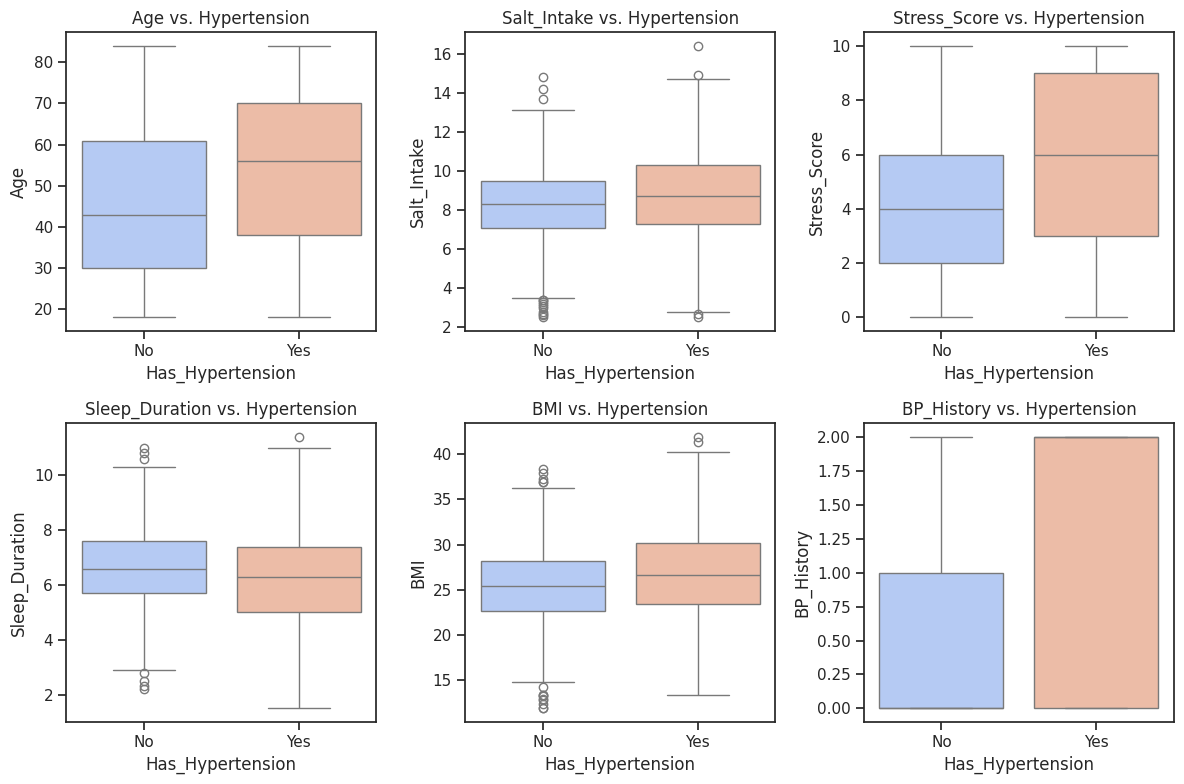

In [ ]:
# Boxplots числовых признаков по классам гипертонии
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='Has_Hypertension', y=col, data=df, palette='coolwarm')
    plt.title(f'{col} vs. Hypertension')
    plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

# На графиках представлены boxplots, сравнивающие различные параметры между группами с гипертонией (Yes) и без неё (No):

## Анализ

1. Возраст (Age vs. Hypertension):
   Люди с гипертонией в среднем старше, медиана смещена вверх.
   Верхний и нижний квартиль выше в группе с гипертонией.

2. Потребление соли (Salt_Intake vs. Hypertension):
   Незначительное повышение потребления соли у гипертоников, но диапазон значений перекрывается.

3. Уровень стресса (Stress_Score vs. Hypertension):
   У гипертоников медианный уровень стресса выше, распределение немного шире.

4. Длительность сна (Sleep_Duration vs. Hypertension):
   У людей с гипертонией медианная продолжительность сна чуть ниже.

5. ИМТ (BMI vs. Hypertension):
   У гипертоников медианное значение ИМТ выше, особенно заметно по верхнему квартилю.

6. История давления (BP_History vs. Hypertension):
   Явная разница: у гипертоников показатели BP_History значительно выше.



## Вывод:

Вероятность наличия гипертонии возрастает с возрастом, увеличением ИМТ, повышенным уровнем стресса, высоким потреблением соли и наличием истории повышенного давления.
Также у гипертоников наблюдается тенденция к меньшей продолжительности сна.
Наиболее сильные различия по группам выявлены по возрасту, ИМТ, уровню стресса и истории давления, что говорит о их важности как факторов риска гипертонии.
Потребление соли и сон хоть и влияют, но не демонстрируют такой явно выраженный тренд, как остальные.

## Матрица корреляций (Correlation Matrix Heatmap)
Дает количественное подтверждение визуальных наблюдений и добавляет информацию о закодированных категориальных признаках.

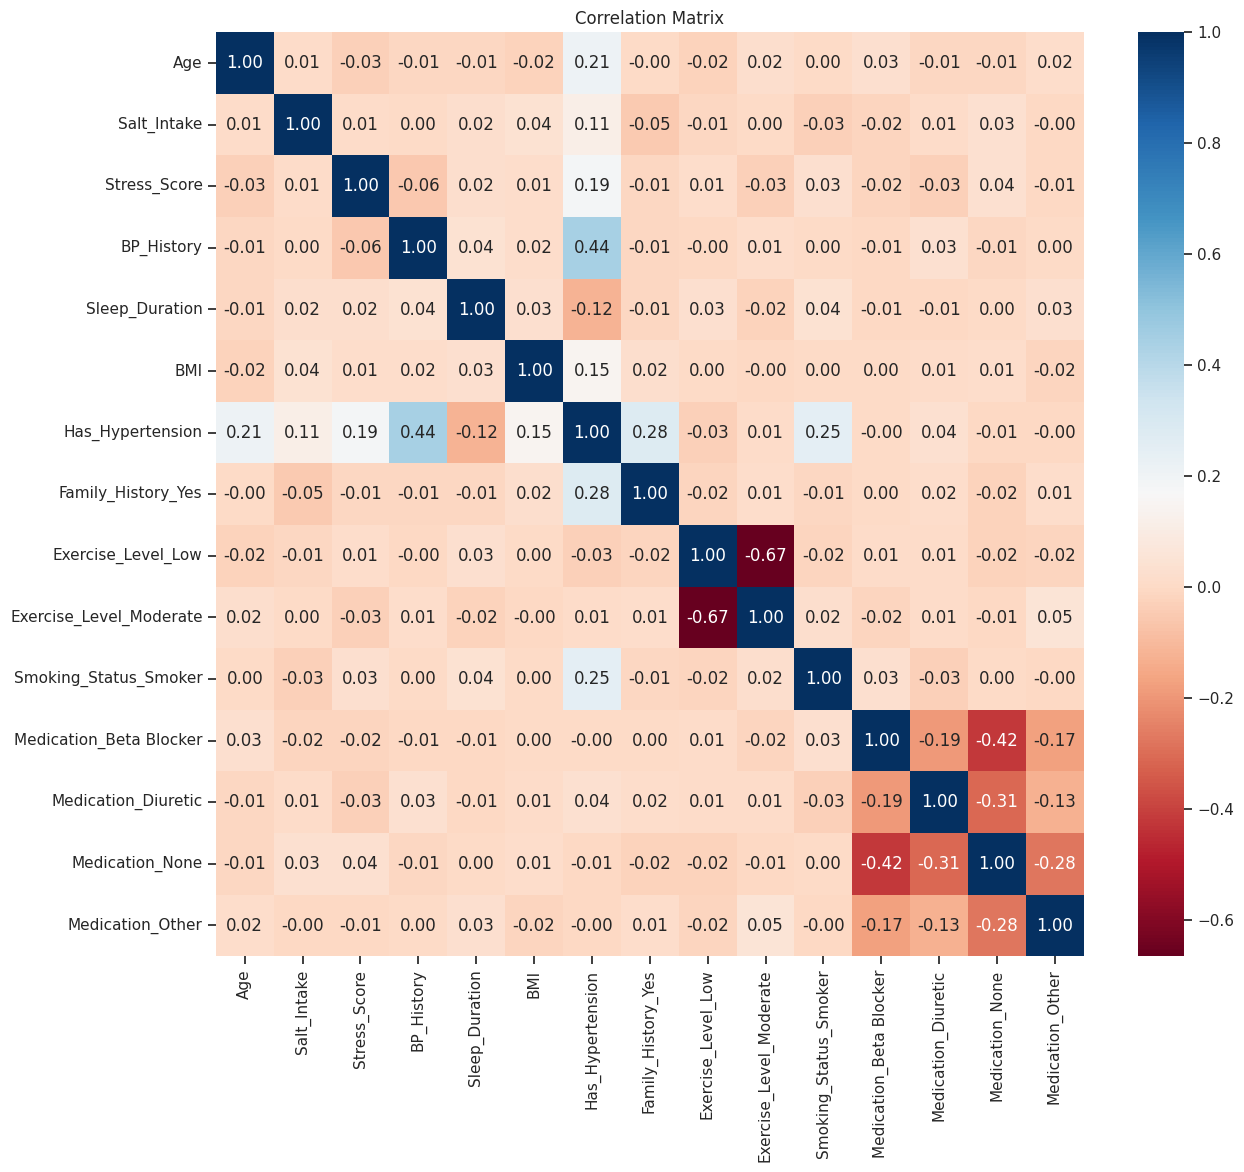

In [ ]:
# Корреляционная матрица по всем признакам
plt.figure(figsize=(14, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()




Анализ корреляции признаков с наличием гипертензии (Has_Hypertension) показывает, что наиболее значимыми факторами являются:

* История артериального давления (BP_History): высокая положительная корреляция (0.442), указывающая на значительное влияние.
* Наличие семейной истории гипертензии (Family_History_Yes): умеренная положительная корреляция (0.282).
* Статус курения (Smoking_Status_Smoker): также положительная корреляция (0.251).

Другие факторы, такие как возраст (0.211) и уровень стресса (0.187), имеют более низкую, но все же положительную корреляцию.

Важно отметить, что корреляция не подразумевает причинно-следственную связь.

## Вывод:
Большинство признаков в наборе данных слабо коррелируют друг с другом. Это является благоприятным фактором для построения статистических и машинного обучения моделей, так как снижает риск мультиколлинеарности. Низкая мультиколлинеарность облегчает интерпретацию моделей и повышает их стабильность и надежность.

In [ ]:
# 6. Масштабирование и разбиение выборки

# Отделяем признаки и целевую переменную
X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension']

# Стратифицированное разбиение, чтобы сохранить пропорции классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Стандартизация признаков (важна перед LDA и PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## В LDA можно оценить важность признаков на основе их вклада в разделение классов. Признаки, которые лучше всего различают классы, будут иметь больший вес в линейной комбинации.

In [ ]:
# 7. Linear Discriminant Analysis (LDA)

print("\n--- 7. Linear Discriminant Analysis (LDA) ---")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
y_pred_lda = lda.predict(X_test_scaled)

# Метрики качества
print("\nLinear Discriminant Analysis Results:")
report = classification_report(y_test, y_pred_lda, output_dict=True)

# Извлечение и вывод только необходимых метрик
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']
f1_score = report['macro avg']['f1-score']

print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1 Score (macro): {f1_score:.4f}")

# Конфузионная матрица
confusion = confusion_matrix(y_test, y_pred_lda)
print("Confusion Matrix:\n", confusion)

# Вычисление "важности" признаков для LDA
if lda.scalings_.ndim == 2 and lda.scalings_.shape[1] > 1:
    feature_importance_lda = np.sum(np.abs(lda.scalings_), axis=1)
else:
    feature_importance_lda = np.abs(lda.scalings_).flatten()

feature_names = X.columns.tolist()
lda_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_LDA': feature_importance_lda
})
lda_importance_df = lda_importance_df.sort_values(by='Importance_LDA', ascending=False)

print("\nТоп-10 информативных признаков по LDA (суммарный абсолютный вклад):")
print(lda_importance_df.head(10).to_string(index=False))
print("\nПримечание: LDA выявляет признаки, наиболее полезные для линейного разделения классов.")



--- 7. Linear Discriminant Analysis (LDA) ---

Linear Discriminant Analysis Results:
Precision (macro): 0.8262
Recall (macro): 0.8266
F1 Score (macro): 0.8261
Confusion Matrix:
 [[160  31]
 [ 38 168]]

Топ-10 информативных признаков по LDA (суммарный абсолютный вклад):
              Feature  Importance_LDA
           BP_History        0.946738
   Family_History_Yes        0.547721
Smoking_Status_Smoker        0.505339
         Stress_Score        0.454936
                  Age        0.432580
       Sleep_Duration        0.312689
          Salt_Intake        0.287106
                  BMI        0.265223
  Medication_Diuretic        0.057056
   Exercise_Level_Low        0.056401

Примечание: LDA выявляет признаки, наиболее полезные для линейного разделения классов.


Модель LDA демонстрирует хорошую, сбалансированную производительность по метрикам.
    Это означает, что модель достаточно хорошо различает пациентов с гипертонией и без нее. Из 191 реального случая без гипертонии, 160 были верно классифицированы (True Negative), 31 ошибочно как с гипертонией (False Positive). Из 206 реальных случаев с гипертонией, 168 были верно классифицированы (True Positive), а 38 ошибочно как без гипертонии (False Negative). Показатели говорят о хорошей предсказательной способности модели.


1. Ключевые признаки: "BP_History" (0.946738) и "Family_History_Yes" (0.547721) имеют наибольшее значение, указывая на важность истории заболеваний.
2. Факторы риска: Признаки "Smoking_Status_Smoker" (0.505339) и "Stress_Score" (0.454936) также существенно влияют на предсказания.
3. Возраст и сон: "Age" (0.432580) и "Sleep_Duration" (0.312689) важны для оценки состояния здоровья.
4. Менее значимые признаки: Последние пять признаков имеют значительно меньшую важность (в пределах 0.057056 - 0.056401).

## PCA может дать представление о том, какие признаки имеют высокую дисперсию


--- 8. Principal Component Analysis (PCA) ---


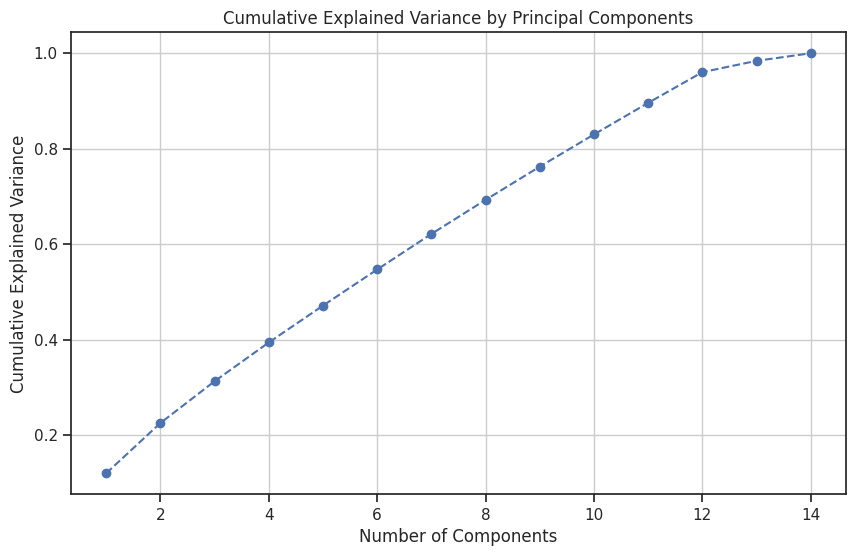


Number of components to explain 95% variance: 12
Shape of X_train_pca: (1588, 12)
Shape of X_test_pca: (397, 12)

Топ-10 информативных признаков по PCA (по сумме абсолютных нагрузок в первых 12 компонентах):
              Feature  Importance_PCA
           BP_History        2.757699
                  BMI        2.705540
Smoking_Status_Smoker        2.692892
          Salt_Intake        2.642499
   Family_History_Yes        2.596544
       Sleep_Duration        2.472825
         Stress_Score        2.352336
                  Age        2.191325
  Medication_Diuretic        2.188772
     Medication_Other        1.946888

Примечание: высокая вкладка в PCA означает большой вклад в общую дисперсию данных, но не обязательно высокую важность для классификации.


In [ ]:
#. Principal Component Analysis (PCA)

print("\n--- Principal Component Analysis (PCA) ---")

# Сначала сохраняем все компоненты для анализа дисперсии
pca_full = PCA(n_components=None)
X_train_pca_full = pca_full.fit_transform(X_train_scaled)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# График кумулятивной объяснённой дисперсии
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Определяем минимальное число компонент, объясняющее >= 95% дисперсии
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f'\nNumber of components to explain 95% variance: {n_components}')

# Применяем PCA с выбранным числом компонент
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape of X_train_pca:", X_train_pca.shape)
print("Shape of X_test_pca:", X_test_pca.shape)

# Вывод информативных признаков по PCA
components = pca.components_

# Суммируем абсолютные значения нагрузок по выбранным компонентам для каждого признака
feature_importance_pca = np.sum(np.abs(components), axis=0)

pca_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_PCA': feature_importance_pca
})
pca_importance_df = pca_importance_df.sort_values(by='Importance_PCA', ascending=False)

print(f"\nТоп-10 информативных признаков по PCA (по сумме абсолютных нагрузок в первых {n_components} компонентах):")
print(pca_importance_df.head(10).to_string(index=False))
print("\nПримечание: высокая вкладка в PCA означает большой вклад в общую дисперсию данных, "
      "но не обязательно высокую важность для классификации.")


если признак имеет высокий вклад в PCA, это означает, что он несет много "информации" в данных в целом.

# Вывод визуального исследования:
▌Важные признаки:

1. BP_History:
  *  Наивысшая важность по LDA и PCA.
  *  Явное разделение классов на pairplot, boxplot и histogram.
  *  Высокий коэффициент корреляции (0.44) с Has_Hypertension.
  *  Вывод: Абсолютно критически важный признак, лучший предиктор.

2. Age:
  *  Высокая важность в LDA и PCA.
  *  Четкое, хотя и не идеальное, разделение по медиане между классами Has_Hypertension на boxplot (возраст у пациентов с гипертонией выше).
  *  Умеренный коэффициент корреляции (0.21) с Has_Hypertension.
  *  Вывод: Важный признак.

3. Family_History_Yes:
  *  Высокая важность в LDA и PCA.
  *  Умеренный коэффициент корреляции (0.28) с Has_Hypertension.
  *  Вывод: Важный признак.

4. Smoking_Status_Smoker:
  *  Высокая важность в LDA и PCA.
  *  Умеренный коэффициент корреляции (0.25) с Has_Hypertension.
  *  Вывод: Важный признак.

5. BMI:
  *  Высокая важность в LDA и PCA.
  *  Некоторое разделение по медиане на boxplot (BMI у пациентов с гипертонией слегка выше).
  *  Умеренный коэффициент корреляции (0.28) с Has_Hypertension.
  *  Вывод: Важный признак.

6. Salt_Intake:
  *  Присутствует в топ-10 LDA и PCA.
  *  Некоторое разделение по медиане на boxplot, но с большим перекрытием.
  *  Слабый, но положительный коэффициент корреляции (0.15) с Has_Hypertension.
  *  Вывод: Важный признак., так как есть вклад в LDA/PCA, и визуально есть некоторая тенденция.

7. Medication_Diuretic:
  *  Присутствует в топ-10 LDA и PCA (особенно высокая позиция в PCA).
  *  Умеренный коэффициент корреляции (0.25) с Has_Hypertension.
  *  Вывод: Важный признак.

8. Stress_Score, Sleep_Duration:
Подтверждается их влияние, хотя и меньшее по сравнению с предыдущими.



  Таким образом:
   
  Для дальнейшего анализа оставим важные признаки, а удалим:
  * 'Medication_Beta Blocker',
  * 'Medication_Other',
  * 'Medication_None',
  * 'Exercise_Level_Moderate',
  * 'Exercise_Level_Low'.
  